In [19]:
#請確保已安裝Herbie(pip install Herbie-data)
from herbie import Herbie

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as feature
import matplotlib.pyplot as plt
import numpy as np

from herbie import paint
from herbie.toolbox import EasyMap, pc
from scipy.interpolate import griddata
import scipy.ndimage

In [20]:
H = Herbie("2026-3-16-00", model="ifs", product="oper", fxx=24)

H.grib, H.idx

✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Mar-16 00:00 UTC F24 ┊ GRIB2 @ google ┊ IDX @ google


('https://storage.googleapis.com/ecmwf-open-data/20260316/00z/ifs/0p25/oper/20260316000000-24h-oper-fc.grib2',
 'https://storage.googleapis.com/ecmwf-open-data/20260316/00z/ifs/0p25/oper/20260316000000-24h-oper-fc.index')

In [21]:
ds_2=H.xarray("10u")
ds_2=ds_2.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_3=H.xarray("10v")
ds_3=ds_3.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_4=H.xarray("10[u|v]").herbie.with_wind()
ds_4=ds_4.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_6=H.xarray(":msl:")
ds_6=ds_6.sel(latitude=slice(25, 21), longitude=slice(112, 116))

C:\Users\andyzhang\anaconda3\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


C:\Users\andyzhang\anaconda3\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 10 m wind(smoothed)')

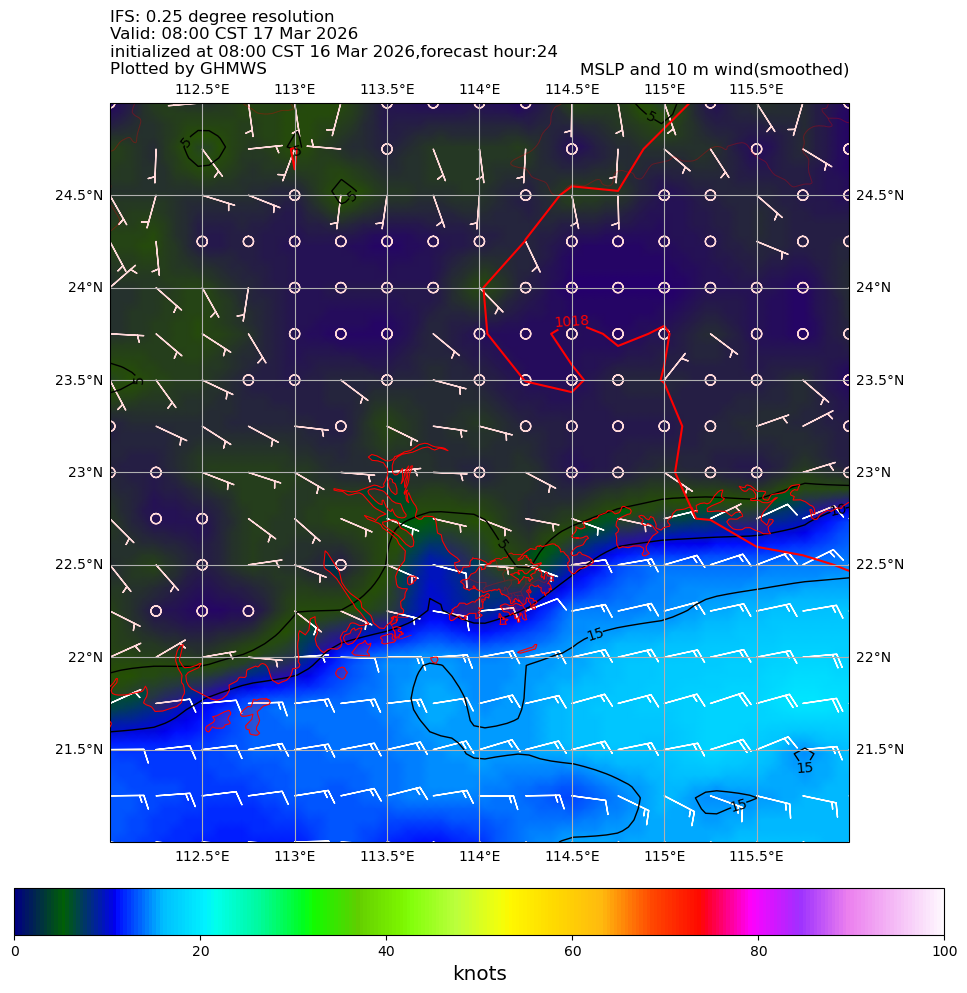

In [22]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12], color='red').STATES().BORDERS().ax
ds_5 = scipy.ndimage.zoom(ds_4.si10, 4, order=1)
longitude = scipy.ndimage.zoom(ds_4.longitude, 4, order=1)
latitude = scipy.ndimage.zoom(ds_4.latitude, 4, order=1)

p = ax.pcolormesh(
    longitude,
    latitude,
    ds_5*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    vmin=0,
    vmax=100,
    shading='gouraud'
)

y = plt.colorbar(p, ax=ax, orientation="horizontal", pad=0.05, cmap='nipy_spectral')
y.set_label('knots', size='x-large')

ax.barbs(ds_2.longitude, ds_3.latitude, ds_2.u10*3.6/1.852, ds_3.v10*3.6/1.852, barbcolor='w')

x = plt.contour(longitude, latitude, ds_5*3.6/1.852, levels=np.arange(0,100,5), colors='k', linewidths=1, transform=pc)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)

z = plt.contour(ds_6.longitude, ds_6.latitude, ds_6.msl/100, levels=np.arange(880,1060,2), colors='red', transform=pc)
plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)

valid_time_cst = ds_4.valid_time + np.timedelta64(8, 'h')
init_time_cst = ds_4.time + np.timedelta64(8, 'h')

ax.set_title(
    f"{ds_4.model.upper()}: 0.25 degree resolution\nValid: {valid_time_cst.dt.strftime('%H:%M CST %d %b %Y').item()}\ninitialized at {init_time_cst.dt.strftime('%H:%M CST %d %b %Y').item()},forecast hour:{H.fxx}\nPlotted by GHMWS",
    loc="left", color='k'
)

gl = ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False

ax.set_title(f"MSLP and 10 m wind(smoothed)", loc="right")